In [1]:
# рисуем остатки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_Advertising = pd.read_csv(r"Advertising.csv")

In [3]:
df_Advertising.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


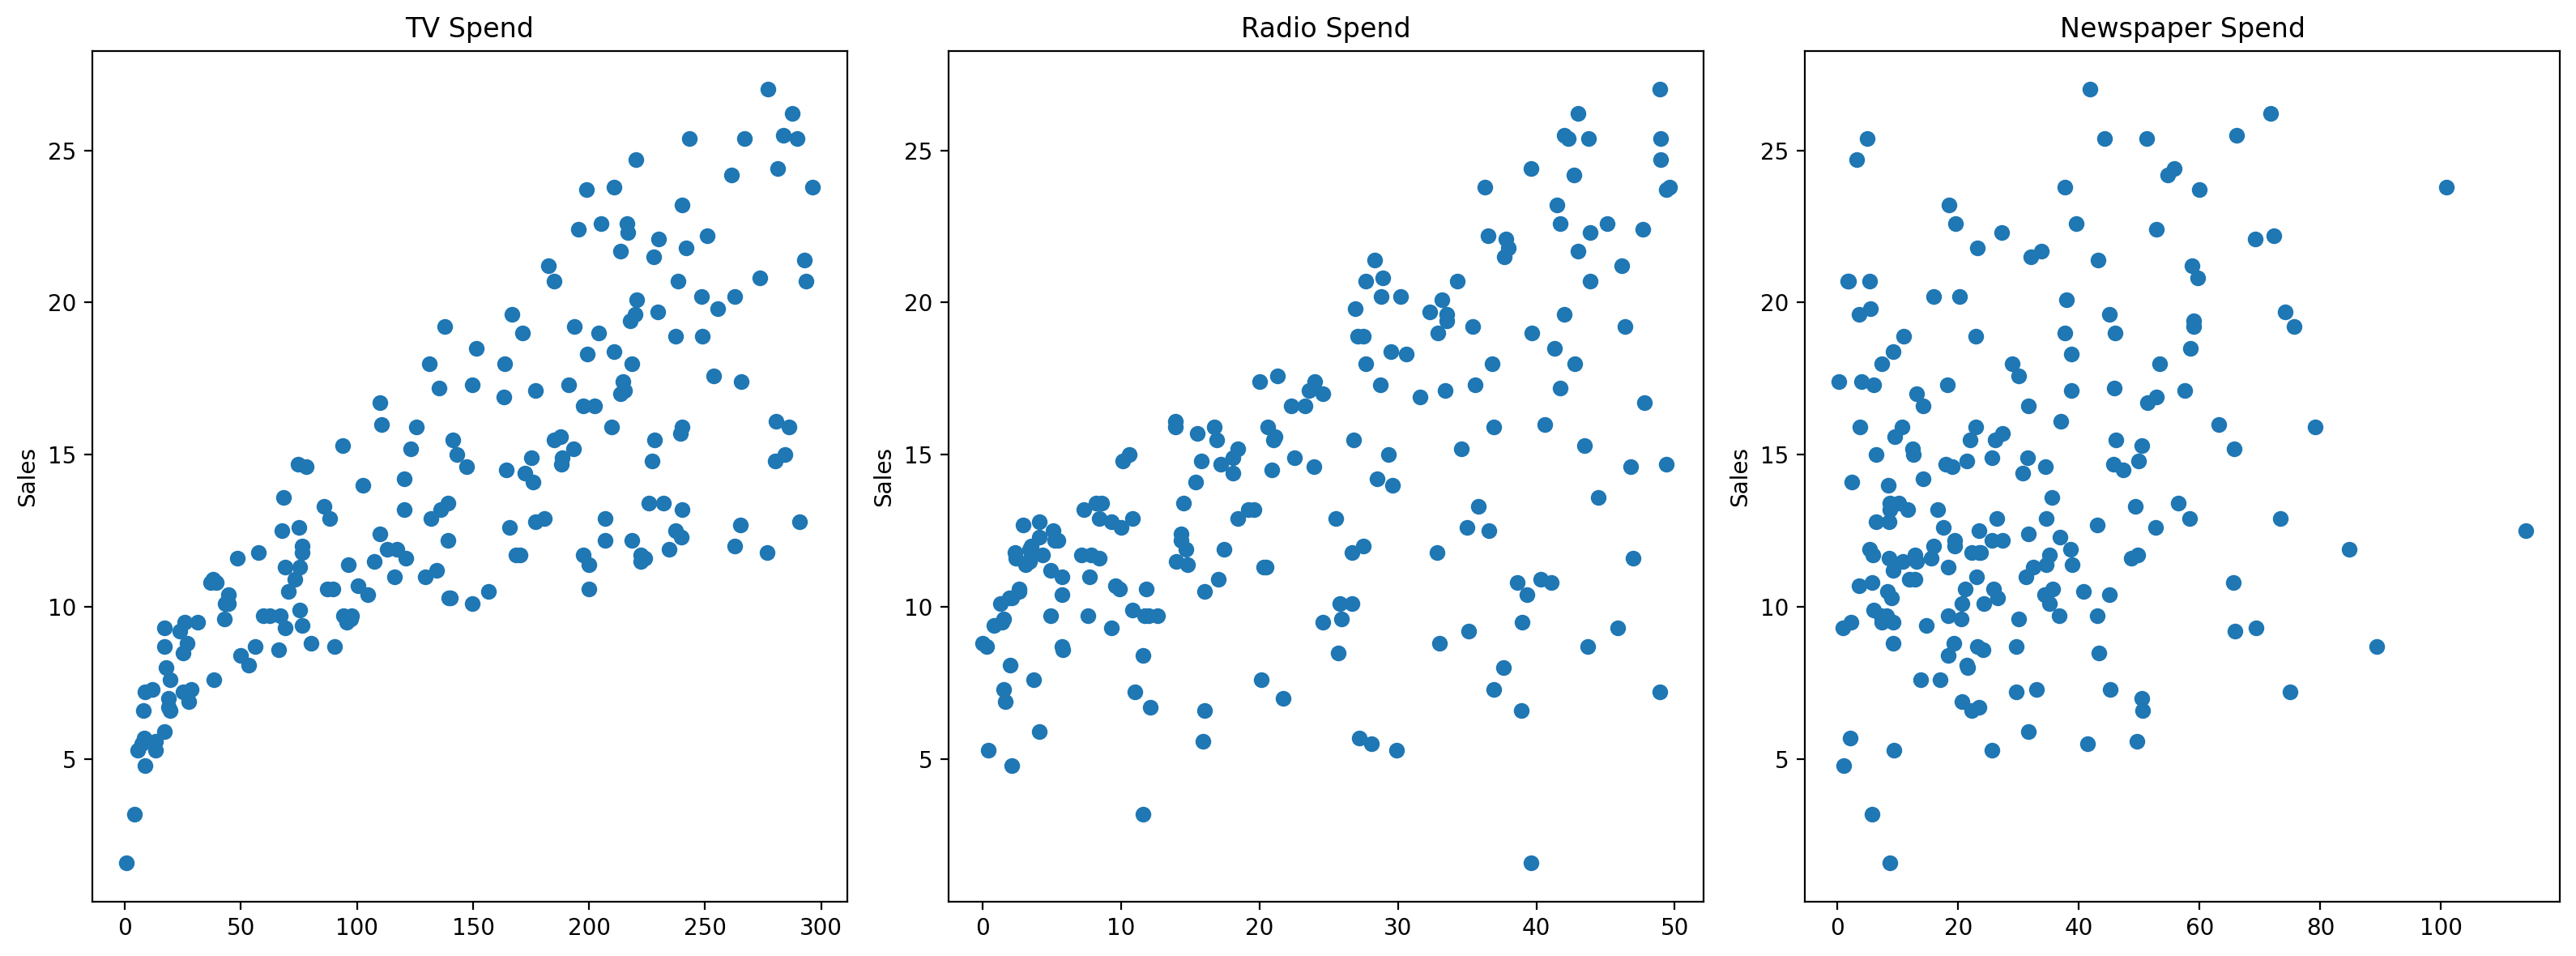

In [4]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6), dpi = 200)

axes[0].plot(df_Advertising['TV'],df_Advertising['sales'],'o')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df_Advertising['radio'],df_Advertising['sales'],'o')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df_Advertising['newspaper'],df_Advertising['sales'],'o')
axes[2].set_title("Newspaper Spend");
axes[2].set_ylabel("Sales")
plt.tight_layout();

In [5]:
#создать график - sns.pairplot()

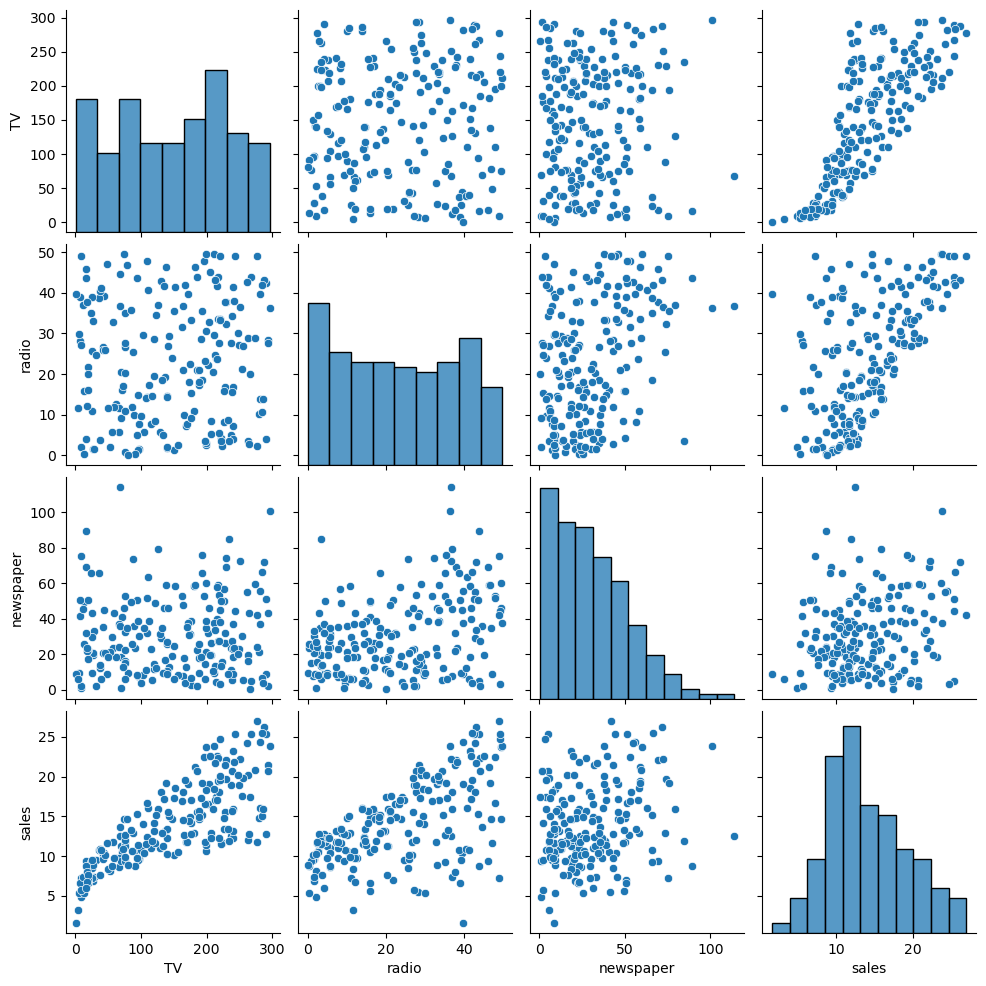

In [6]:
sns.pairplot(df_Advertising)

# разбиение данных

In [8]:
X_adv = df_Advertising.drop('sales', axis=1)
y_adv = df_Advertising['sales']

In [9]:
# разбиение

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_adv, y_adv, test_size=0.3, random_state=101)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model_linear = LinearRegression()

In [14]:
model_linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_predict = model_linear.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
mean = df_Advertising['sales'].mean()
mean

np.float64(14.0225)

<Axes: xlabel='sales', ylabel='Count'>

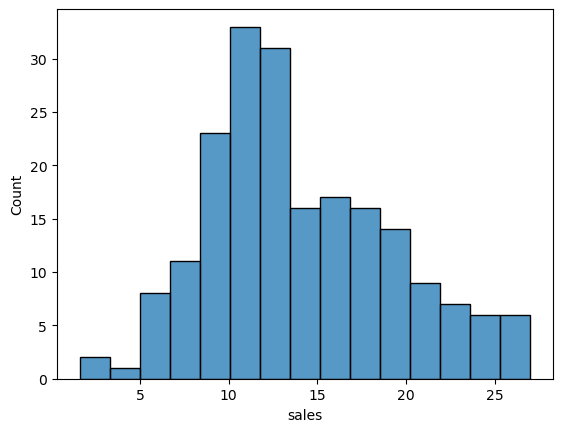

In [18]:
sns.histplot(data=df_Advertising, x='sales', bins=15)

In [19]:
mean_squared_error(y_test, y_predict)

2.2987166978863796

In [20]:
MAE = mean_absolute_error(y_test, y_predict)
MAE

1.213745773614481

# можно сравнивать среднее нашего таргета и меан абсолют. и понимать насколько большая ошибка

In [21]:
print(f"Ошибка составляет {MAE / mean * 100:.2f}% от среднего")

Ошибка составляет 8.66% от среднего


----
# График Остатков
****

In [22]:
residuals = y_test - y_predict

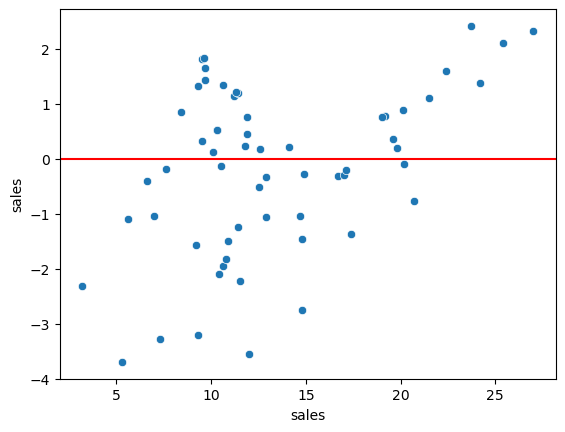

In [23]:
sns.scatterplot(x = y_test, y = residuals)
plt.axhline(y=0, c='r')

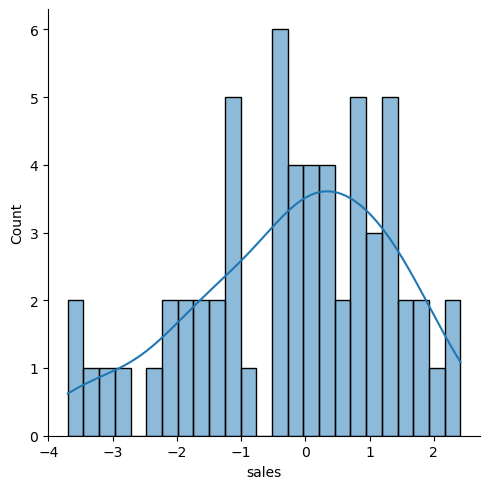

In [24]:
sns.displot(residuals, bins=25, kde=True)

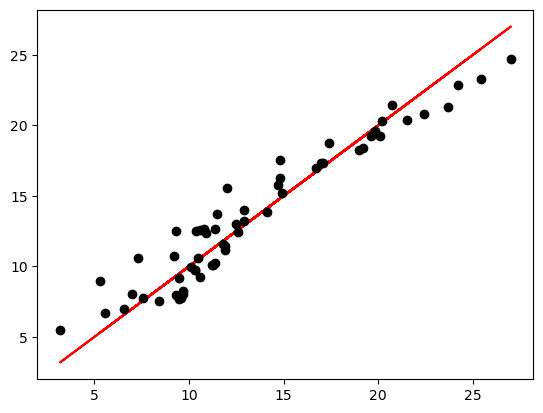

In [25]:
plt.plot(y_test, y_test, c="r")
plt.plot(y_test, y_predict, "ko")

----
### Это тоже поможет посмотреть нам на то, как остатки выделяются